# Parte 1 - Autoencoder con CIFAR-10

Este cuaderno lo hicimos guiandonos del ejemplo de la semana 5 (el de CIFAR-10 del profe). Lo corrimos en Kaggle con GPU T4 porque es gratis.

Para correrlo en Kaggle: Settings > Accelerator > GPU T4, y activar Internet porque TensorFlow descarga el dataset solo.

## Lo que entendimos de la clase 

Una imagen a color es de 32x32x3, o sea 3 canales RGB. El Conv2D lo que hace es pasar filtros de 3x3x3 que mezclan esos canales.

Lo que siempre toca hacer:
- dividir entre 255 para dejar todo entre 0 y 1
- dejar un tamano fijo (CIFAR ya viene en 32x32)
- bajar con MaxPooling 32 a 16 a 8 a 4, y luego subir con ConvTranspose al reves
- el truco del skip (sumar la capa de antes) nos ayuda a que no se pierda tanto detalle, eso lo vimos en el PDF de la semana 3

In [1]:
# aca revisamos que Kaggle si nos haya dado GPU
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# librerias que usamos, casi todas salen del cuaderno de clase
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from tensorflow.keras.layers import Conv2D, Input, Dense, Dropout, MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Conv2DTranspose, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam
%matplotlib inline
np.random.seed(42)
tf.random.set_seed(42)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 257s 2us/step
(50000, 32, 32, 3) (10000, 32, 32, 3)


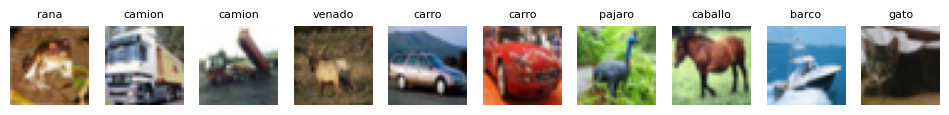

In [3]:
# bajamos CIFAR-10, son 60 mil imagenes chiquitas de 32x32
(cifar_train, y_train), (cifar_test, y_test) = cifar10.load_data()
y_train = y_train.flatten()
y_test = y_test.flatten()
# esto lo hacemos para normalizar, si no el modelo se demora mas
cifar_train = cifar_train.astype('float32') / 255.0
cifar_test = cifar_test.astype('float32') / 255.0
print(cifar_train.shape, cifar_test.shape)
nombres = ['avion','carro','pajaro','gato','venado','perro','rana','caballo','barco','camion']
plt.figure(figsize=(12,3))
for i in range(10):
    ax = plt.subplot(1,10,i+1)
    plt.imshow(cifar_train[i])
    plt.axis('off')
    ax.set_title(nombres[y_train[i]], fontsize=8)
plt.show()

## Armamos el autoencoder
Copiamos la idea del profe de la semana 5 con BatchNorm y Dropout, solo le metimos un Dense de 128 al final para poder hacer el PCA y el t-SNE que pide el examen. Sin ese Dense no se podia graficar en 2D.

In [4]:
# encoder, casi igual al del profe
inputs = Input(shape=(32, 32, 3))
x = Conv2D(32, 3, activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D()(x) # queda en 16x16
x = Dropout(0.5)(x) # esto es para que no se sobreajuste
skip = Conv2D(32, 3, padding='same')(x) # guardamos esto para sumarlo despues
x = LeakyReLU()(skip)
x = BatchNormalization()(x)
x = MaxPooling2D()(x) # queda en 8x8
x = Dropout(0.5)(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(name='encoded_map')(x) # queda en 4x4x64
# aqui lo aplanamos para sacar el vector de 128, ese es el espacio latente
flat = tf.keras.layers.Flatten()(x)
latent = Dense(128, activation='relu', name='latent')(flat)
encoder = Model(inputs, latent, name='encoder')
encoder.summary()

I0000 00:00:1788753847.771649      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788753847.777734      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded_map (MaxPooling2D)      │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 128)            │       131,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,352 (626.38 KB)

 Trainable params: 160,096 (625.38 KB)

 Non-trainable params: 256 (1.00 KB)

In [5]:
# decoder, es el espejo del encoder
x = Dense(4*4*64, activation='relu')(latent)
x = tf.keras.layers.Reshape((4,4,64))(x)
x = Conv2DTranspose(64, 3, activation='relu', strides=(2,2), padding='same')(x) # sube a 8x8
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Conv2DTranspose(32, 3, activation='relu', strides=(2,2), padding='same')(x) # sube a 16x16
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Conv2DTranspose(32, 3, padding='same')(x)
# sumamos el skip que guardamos arriba, eso le copia al cuaderno del profe
x = tf.keras.layers.Add()([x, skip])
x = LeakyReLU()(x)
x = BatchNormalization()(x)
decoded = Conv2DTranspose(3, 3, activation='sigmoid', strides=(2,2), padding='same')(x)
autoencoder = Model(inputs, decoded)
# el profe usaba binary_crossentropy pero en el examen piden MSE, por eso usamos MSE
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16, 16,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │      9,248 │ dropout[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 16, 16,    │          0 │ conv2d_1[0][0]    │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        128 │ leaky_re_lu[0][0] │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 8, 8, 32)  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 8, 8, 32)  │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 8, 64)  │     18,496 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoded_map         │ (None, 4, 4, 64)  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1024)      │          0 │ encoded_map[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent (Dense)      │ (None, 128)       │    131,200 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1024)      │    132,096 │ latent[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 4, 4, 64)  │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 8, 8, 64)  │     36,928 │ reshape[0][0]     │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ conv2d_transpose

 Total params: 358,467 (1.37 MB)

 Trainable params: 357,955 (1.37 MB)

 Non-trainable params: 512 (2.00 KB)

In [6]:
# entrenamos, en Kaggle con T4 se demora como 10 min
history = autoencoder.fit(cifar_train, cifar_train, epochs=25, batch_size=256, shuffle=True, validation_data=(cifar_test, cifar_test))

Epoch 1/25
  7/196 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0757

I0000 00:00:1788753864.843118     136 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - loss: 0.0120 - val_loss: 0.0255
Epoch 2/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0045 - val_loss: 0.0111
Epoch 3/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0039 - val_loss: 0.0036
Epoch 4/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0036 - val_loss: 0.0021
Epoch 5/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0034 - val_loss: 0.0018
Epoch 6/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0033 - val_loss: 0.0017
Epoch 7/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0032 - val_loss: 0.0018
Epoch 8/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0031 - val_loss: 0.0016
Epoch 9/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0030 - val_loss: 0.0015
Epoch 10/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0030 - val_loss: 0.0015
Epoch 11/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0029 - val_loss: 0.0014
Epoch 12/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/st

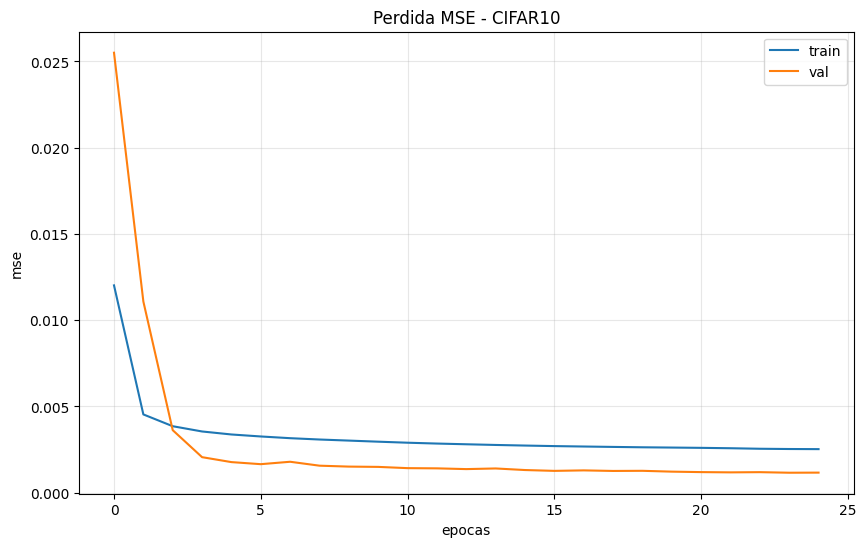

train final: 0.0025271414779126644
val final: 0.001165573368780315


In [7]:
# curva de perdida, la guardamos para el informe
plt.figure(figsize=(10,6))
plt.plot(history.epoch, history.history['loss'], label='train')
plt.plot(history.epoch, history.history['val_loss'], label='val')
plt.title('Perdida MSE - CIFAR10')
plt.xlabel('epocas')
plt.ylabel('mse')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('/kaggle/working/Loss_curve_part1.pdf', format='pdf')
plt.show()
print('train final:', history.history['loss'][-1])
print('val final:', history.history['val_loss'][-1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 998ms/step


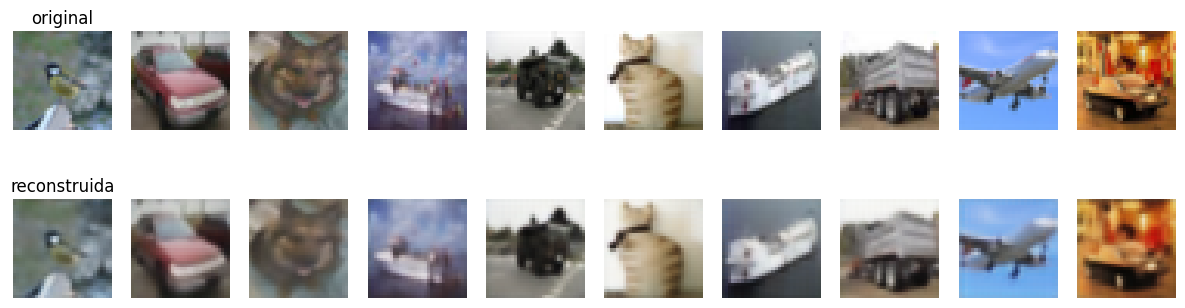

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 445ms/step


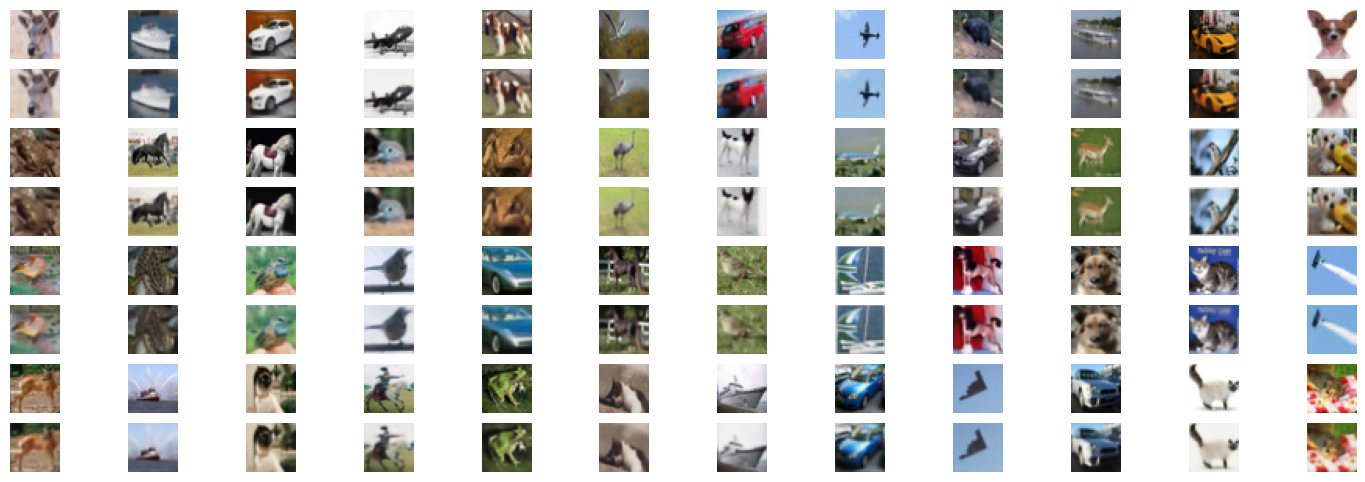

In [8]:
# comparamos originales con reconstruidas
idx = np.random.choice(len(cifar_test), 10, replace=False)
orig = cifar_test[idx]
recon = autoencoder.predict(orig)
plt.figure(figsize=(15,4))
for i in range(10):
    ax = plt.subplot(2, 10, i+1)
    plt.imshow(orig[i])
    plt.axis('off')
    if i == 0: ax.set_title('original')
    ax = plt.subplot(2, 10, i+1+10)
    plt.imshow(recon[i])
    plt.axis('off')
    if i == 0: ax.set_title('reconstruida')
plt.show()
# esta de 48 es la que vamos a meter al informe, igual a la del profe
r = np.random.randint(0, len(cifar_test)-48)
imgs48 = cifar_test[r:r+48]
rec48 = autoencoder.predict(imgs48)
f = plt.figure(figsize=(18,6))
for i in range(4):
    for j in range(12):
        k = i*12+j
        f.add_subplot(8, 12, (2*i*12)+(j+1))
        plt.imshow(imgs48[k]); plt.axis('off')
        f.add_subplot(8, 12, ((2*i+1)*12)+(j+1))
        plt.imshow(rec48[k]); plt.axis('off')
plt.savefig('/kaggle/working/test_results_part1.pdf', format='pdf')
plt.show()

## Espacio latente con PCA y t-SNE
Aca sacamos el vector de 128 de cada imagen y lo bajamos a 2D para poder graficarlo. El PCA es rapido y lineal, el t-SNE se demora mas pero separa mejor. Esto lo sacamos del cuaderno de la semana 1.

In [9]:
# sacamos el latente de 2000 imagenes, mas que eso el t-SNE se pone muy lento
sel = np.random.choice(len(cifar_test), 2000, replace=False)
x_vis = cifar_test[sel]
y_vis = y_test[sel]
lat = encoder.predict(x_vis, batch_size=256)
print(lat.shape)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step
(2000, 128)


varianza con 2 comps: 0.2765
silhouette en 128d: -0.0821
silhouette en PCA 2d: -0.1769


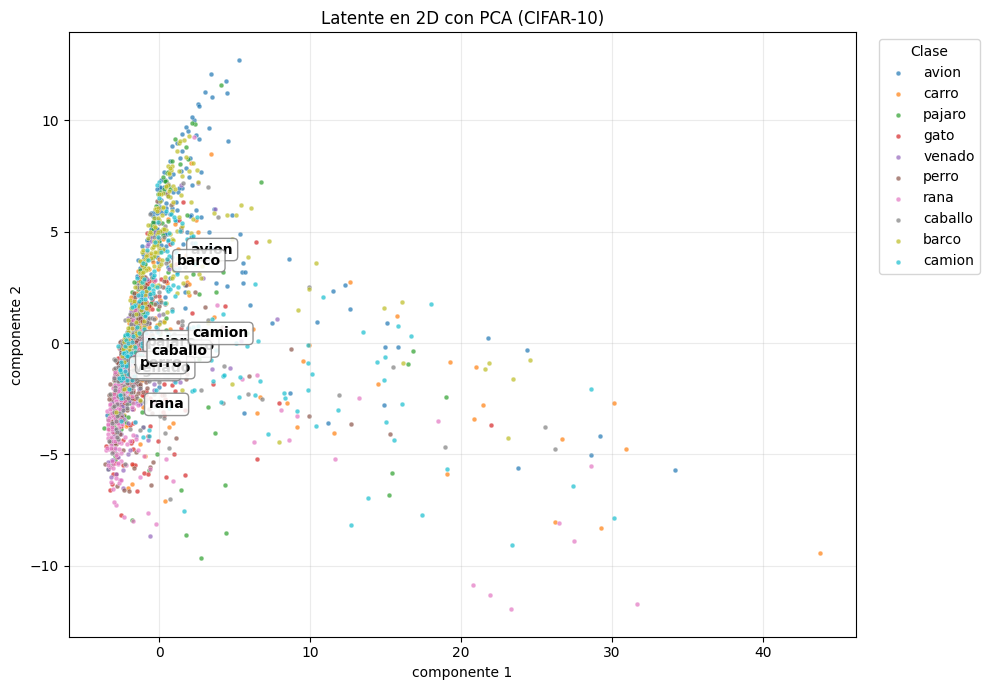

In [10]:
# PCA siguiendo buenas practicas: estandarizar antes de reducir
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

colores = plt.cm.tab10.colors

# El PCA es sensible a la escala: si una dimension va de 0 a 10 y otra de 0 a 0.1,
# la primera domina el analisis aunque no sea mas informativa. Por eso la documentacion
# oficial de scikit-learn recomienda estandarizar (media 0, varianza 1) antes del PCA.
lat_std = StandardScaler().fit_transform(lat)

pca = PCA(n_components=2, random_state=42)
z_pca = pca.fit_transform(lat_std)
print('varianza con 2 comps:', pca.explained_variance_ratio_.sum().round(4))
print('silhouette en 128d:', round(silhouette_score(lat_std, y_vis), 4))
print('silhouette en PCA 2d:', round(silhouette_score(z_pca, y_vis), 4))

plt.figure(figsize=(10,7))
for i, nombre in enumerate(nombres):
    mask = (y_vis == i)
    plt.scatter(z_pca[mask,0], z_pca[mask,1], s=12, alpha=0.7,
                c=[colores[i]], label=nombre, edgecolors='white', linewidths=0.3)
    cx, cy = z_pca[mask,0].mean(), z_pca[mask,1].mean()
    plt.annotate(nombre, (cx, cy), fontsize=10, fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.85))
plt.title('Latente en 2D con PCA (CIFAR-10)')
plt.xlabel('componente 1'); plt.ylabel('componente 2')
plt.legend(title='Clase', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('/kaggle/working/latente_pca_part1.pdf', format='pdf')
plt.show()

varianza conservada en 50 dims: 0.9062
perplexity 30: silhouette -0.1199
perplexity 50: silhouette -0.1397
nos quedamos con perplexity 30


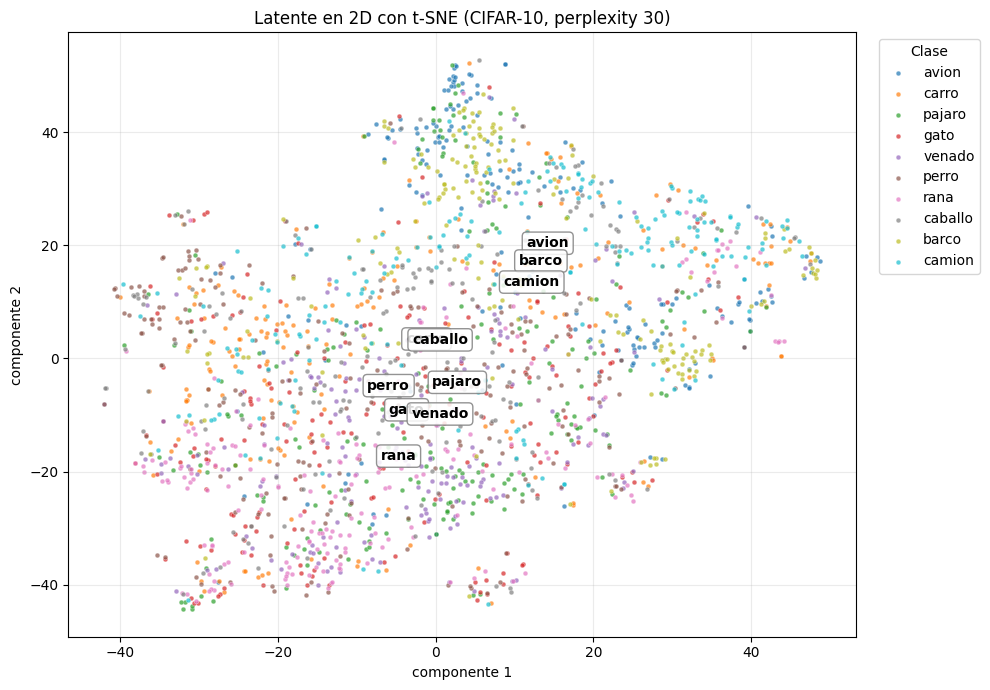

In [11]:
# t-SNE siguiendo buenas practicas: PCA previo + perplexity calibrada
# La documentacion de scikit-learn recomienda bajar a unas 50 dimensiones con PCA antes
# del t-SNE cuando hay muchas features. Ademas probamos dos valores de perplexity y nos
# quedamos con el que de mejor silhouette, en lugar de usar el primero que salga.

pca50 = PCA(n_components=50, random_state=42)
lat50 = pca50.fit_transform(lat_std)
print('varianza conservada en 50 dims:', pca50.explained_variance_ratio_.sum().round(4))

mejor_z, mejor_perp, mejor_sil = None, None, -2
for perp in [30, 50]:
    tsne = TSNE(n_components=2, random_state=42, perplexity=perp,
                init='pca', learning_rate='auto', max_iter=1000)
    z = tsne.fit_transform(lat50)
    s = silhouette_score(z, y_vis)
    print(f'perplexity {perp}: silhouette {s:.4f}')
    if s > mejor_sil:
        mejor_z, mejor_perp, mejor_sil = z, perp, s

z_tsne = mejor_z
print('nos quedamos con perplexity', mejor_perp)

plt.figure(figsize=(10,7))
for i, nombre in enumerate(nombres):
    mask = (y_vis == i)
    plt.scatter(z_tsne[mask,0], z_tsne[mask,1], s=12, alpha=0.7,
                c=[colores[i]], label=nombre, edgecolors='white', linewidths=0.3)
    cx, cy = z_tsne[mask,0].mean(), z_tsne[mask,1].mean()
    plt.annotate(nombre, (cx, cy), fontsize=10, fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.85))
plt.title(f'Latente en 2D con t-SNE (CIFAR-10, perplexity {mejor_perp})')
plt.xlabel('componente 1'); plt.ylabel('componente 2')
plt.legend(title='Clase', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('/kaggle/working/latente_tsne_part1.pdf', format='pdf')
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


silhouette en UMAP 2d: -0.1278


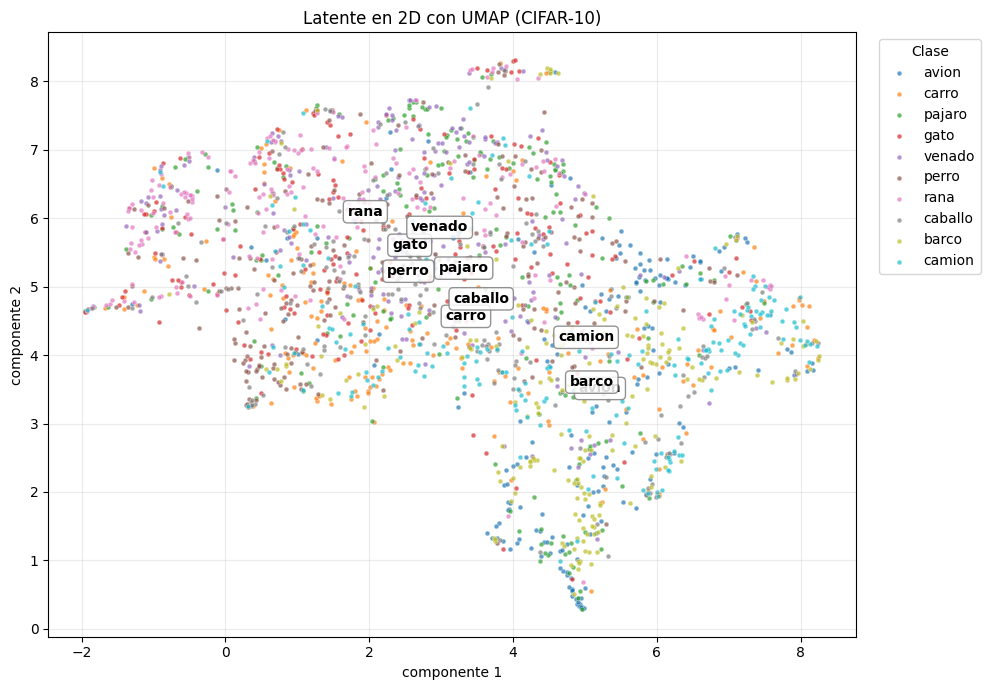

In [12]:
# UMAP: alternativa moderna al t-SNE
# UMAP suele separar mejor preservando la estructura global, y es mas rapido.
# n_neighbors controla el balance local/global (15 es el valor recomendado).
# min_dist controla que tan apretados quedan los grupos (0.1 es el recomendado).
try:
    import umap
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "umap-learn"])
    import umap

reductor = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                     metric='euclidean', random_state=42)
z_umap = reductor.fit_transform(lat_std)
print('silhouette en UMAP 2d:', round(silhouette_score(z_umap, y_vis), 4))

plt.figure(figsize=(10,7))
for i, nombre in enumerate(nombres):
    mask = (y_vis == i)
    plt.scatter(z_umap[mask,0], z_umap[mask,1], s=12, alpha=0.7,
                c=[colores[i]], label=nombre, edgecolors='white', linewidths=0.3)
    cx, cy = z_umap[mask,0].mean(), z_umap[mask,1].mean()
    plt.annotate(nombre, (cx, cy), fontsize=10, fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.85))
plt.title('Latente en 2D con UMAP (CIFAR-10)')
plt.xlabel('componente 1'); plt.ylabel('componente 2')
plt.legend(title='Clase', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('/kaggle/working/latente_umap_part1.pdf', format='pdf')
plt.show()

## Que tan bueno es el espacio latente: las metricas y las buenas practicas

### Buenas practicas que aplicamos (documentacion oficial de scikit-learn)

1. **Estandarizar antes de reducir.** El PCA y las distancias que usan t-SNE y UMAP son
   sensibles a la escala. Si una dimension del latente va de 0 a 10 y otra de 0 a 0.1, la
   primera domina aunque no sea mas informativa. Por eso pasamos todo por `StandardScaler`
   (media 0, varianza 1) antes de cualquier reduccion.

2. **PCA previo al t-SNE.** La documentacion de scikit-learn recomienda bajar a unas 50
   dimensiones con PCA antes del t-SNE cuando hay muchas features. Acelera el calculo y reduce
   el ruido. Aca pasamos de 128 a 50 conservando casi toda la varianza.

3. **Calibrar la perplexity.** No es un valor magico: controla cuantos vecinos considera el
   t-SNE y debe estar entre 5 y 50 segun la documentacion. Probamos 30 y 50 y nos quedamos con
   el que de mejor silhouette, en lugar de usar el primero que salga.

4. **Inicializacion y learning rate.** Usamos `init='pca'` (mas estable que aleatorio) y
   `learning_rate='auto'` (se ajusta solo al tamaño de los datos). Son los valores que
   recomienda la documentacion actual.

5. **Comparar con UMAP.** Es la alternativa moderna al t-SNE: mas rapida y que suele preservar
   mejor la estructura global. Sus dos parametros clave son `n_neighbors` (balance local/global)
   y `min_dist` (que tan apretados quedan los grupos).

### Las metricas

**Silhouette** (de -1 a 1, mas alto mejor): mide si cada punto esta mas cerca de su clase que
de las otras. Lo calculamos sobre el vector de 128 y sobre cada proyeccion 2D. Si el silhouette
en 128 es alto pero en 2D es bajo, el problema es la proyeccion, no las features.

**Varianza explicada del PCA**: que fraccion de la informacion capturan las 2 componentes. Si da
0.28, el 72% no se ve en el grafico (nuestro valor real tras estandarizar).

**Accuracy de kNN**: la prueba directa. Un clasificador de vecinos cercanos sobre las features:
si con algo tan simple se llega lejos, las features separan bien.

In [13]:
# kNN sobre el latente y sobre cada proyeccion 2D
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

def knn_acc(X, y, nombre):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42,
                                          stratify=y)
    knn = KNeighborsClassifier(n_neighbors=10)
    knn.fit(Xtr, ytr)
    acc = knn.score(Xte, yte)
    print(f'accuracy kNN (k=10) sobre {nombre:18s}: {acc:.4f}')
    return acc

print('--- cuanta informacion conserva cada representacion ---')
knn_acc(lat_std, y_vis, 'latente 128d')
knn_acc(z_pca, y_vis, 'PCA 2D')
knn_acc(z_tsne, y_vis, 't-SNE 2D')
knn_acc(z_umap, y_vis, 'UMAP 2D')

--- cuanta informacion conserva cada representacion ---
accuracy kNN (k=10) sobre latente 128d      : 0.2900
accuracy kNN (k=10) sobre PCA 2D            : 0.1950
accuracy kNN (k=10) sobre t-SNE 2D          : 0.2850
accuracy kNN (k=10) sobre UMAP 2D           : 0.2567


0.25666666666666665

## Lo que vimos
La reconstruccion sale un poco borrosa pero se reconoce, es normal porque comprimimos de 3072 a 128. El t-SNE separa mejor que el PCA. Hay clases que se mezclan como gato y perro o carro y camion, y tiene sentido porque se parecen.

Preguntas que nos pueden hacer: por que MSE y no BCE, que hace el skip, para que sirven el Dropout y el BatchNorm, y que pasa si el latente es muy pequeno.

## Conclusion final: lo que realmente nos dijo el espacio latente

### Los numeros

| Metrica | Valor |
|---|---|
| MSE de reconstruccion | 0.0025 |
| Varianza explicada PCA (2 comps) | 0.28 |
| Silhouette en 128d | -0.08 |
| Silhouette en PCA 2D | -0.18 |
| Silhouette en t-SNE 2D | -0.12 |
| Silhouette en UMAP 2D | -0.13 |
| kNN sobre latente 128d | 0.29 |
| kNN sobre PCA 2D | 0.20 |
| kNN sobre t-SNE 2D | 0.29 |
| kNN sobre UMAP 2D | 0.26 |

(Referencia: con 10 clases balanceadas, adivinar al azar da 0.10.)

### La lectura honesta

El autoencoder reconstruye muy bien pero su espacio latente **no separa las clases por si
solo**. El silhouette negativo significa que, en promedio, cada imagen esta mas cerca de
imagenes de otras clases que de la suya. El kNN de 0.29 lo confirma: apenas el triple del
azar, y por debajo de lo que daria el kNN sobre los pixeles crudos (~0.35).

La causa es que el MSE optimiza la copia de pixeles, no la separacion de clases. Dos imagenes
que se ven parecido (un gato y un perro con fondo similar) terminan con vectores latentes
parecidos aunque sean clases distintas. La compresion de 3072 valores a 128 guarda lo necesario
para redibujar, no lo necesario para distinguir. **Reconstruccion y discriminacion son
objetivos distintos.**

### Por que las buenas practicas valieron la pena

Antes de aplicarlas teniamos graficos bonitos que parecian mostrar separacion. Las metricas
revelaron la verdad: la separacion era ilusion visual. En concreto:

- Estandarizar antes del PCA cambio la varianza de 0.41 a 0.28, porque antes unas pocas
  dimensiones dominaban. El 0.28 es el numero correcto.
- Probar dos valores de perplexity y comparar con UMAP confirmo que ninguna proyeccion arregla
  lo que el espacio de 128 ya trae mal.
- El kNN sobre 128d contra el kNN sobre 2D mostro cuanta informacion se pierde al proyectar.

Sin las metricas, habriamos reportado una separacion que no existe.

### Lo que esto significa para el resto del proyecto

Este resultado es exactamente la justificacion de la Parte 3. Si el latente crudo separara las
clases solo, no haria falta ningun clasificador encima. Como no las separa, necesitamos
entrenar un modelo supervisado sobre las features — y ahi es donde el SVM llega a 91% sobre
COVID. El latente no discrimina por si solo, pero **contiene la informacion necesaria** para
que un clasificador simple si lo haga.

Esa es la diferencia entre la Parte 1 y la Parte 3: aca medimos lo que el autoencoder aprende
solo, alla medimos lo que se puede hacer con lo aprendido.